## **Parte IV**
Implementação das tarefas 17 a 20

---


In [1]:
import os
import time

import psycopg2
from psycopg2 import sql, errors
import getpass

In [2]:
## Criando o Database
DB_SUPER = "postgres"
DB_USER = "jaidezardin"
DB_HOST = os.getenv("PGHOST", "localhost")
DB_PORT = int(os.getenv("PGPORT", 5432))

NEW_DB = "reservas"
NEW_TABLE = "Assentos"

conn = psycopg2.connect(dbname=DB_SUPER, user=DB_USER, host=DB_HOST, port=DB_PORT)
conn.autocommit = True
cur = conn.cursor()
try:
    cur.execute(sql.SQL("CREATE DATABASE {}").format(sql.Identifier(NEW_DB)))
    print(f"Banco de dados {NEW_DB} criado.")
except errors.DuplicateDatabase:
    print(f"Banco de dados {NEW_DB} já existe.")
finally:
    cur.close()
    conn.close()

Banco de dados reservas já existe.


In [3]:
## Criando a tabela

conn = psycopg2.connect(dbname=NEW_DB, user=DB_USER, host=DB_HOST, port=DB_PORT)
cur = conn.cursor()

cur.execute(sql.SQL(f"""
CREATE TABLE IF NOT EXISTS {NEW_TABLE} (
num_voo integer,
disp bool,
primary key (num_voo),
check (num_voo > 0),
check (num_voo <= 200)
)
""")
)

conn.commit()
cur.close()
conn.close()


## Tarefa 17
### As duas versões da transação de reserva

A versão A realiza todos os processo em uma única transação, realizando commit apenas no final. Já a versão B realiza a seleção dos assentos disponíveis em uma transação, e depois realiza a atualização em outra transação separada.



In [4]:
## Transações
import random

system_random = random.Random()

def reserva_version_a(conn, isolation_level="READ COMMITTED"):
    cur = conn.cursor()
    try:
        # Define o nível da transação
        cur.execute(f"set transaction isolation level {isolation_level}")
        # Seleciona os assentos disponíveis
        cur.execute("select num_voo from Assentos where disp = true for update")
        open = cur.fetchall()

        # Caso não haja assentos disponíveis, rollback
        if not open:
            conn.rollback()
            return None

        # Dorme por 1 segundo e escolhe aleatoriamente um assento
        time.sleep(0.1)
        chosen = system_random.choice(open)[0]

        # Atualiza a tabela de assentos, marcando o assento escolhido como ocupado
        cur.execute(
            """
            update assentos set disp = false where num_voo = %s and disp = true
            """,
            (chosen,)
        )

        # Caso não haja nenhuma linha afetada, rollback
        if cur.rowcount == 0:
            conn.rollback()
            return None

        # Commit da transação
        conn.commit()
        return chosen
    except Exception as e:
        conn.rollback()
        print(f"Erro na reserva versão A: {e}")
        return None
    finally:
        cur.close()


def reserva_version_b(conn, isolation_level="READ COMMITTED"):
    cur = conn.cursor()
    try:
        # Define o nível de isolamento
        cur.execute(f"set transaction isolation level {isolation_level}")

        # Seleciona os assentos disponíveis
        cur.execute("select num_voo from Assentos where disp = true for update")
        open = cur.fetchall()
        # Commit dessa primeira transação
        conn.commit()

        # Caso não haja nenhum elemento dentro, rollback
        if not open:
            conn.rollback()
            return None

        # Dorme por 1 segundo e escolhe aleatoriamente um assento (sem estar na transação anterior)
        time.sleep(0.1)
        chosen = system_random.choice(open)[0]

        # Define o nível de isolamento da próxima transação
        cur.execute(f"set transaction isolation level {isolation_level}")
        # Tenta atualizar a tabela de assentos, marcando o assento escolhido como ocupado
        cur.execute (
            "update Assentos set disp = false where num_voo = %s and disp = true",
            (chosen,)
        )

        # Se atualizou, commit, se não, rollback
        if cur.rowcount == 0:
            conn.rollback()
            return None
        conn.commit()
        return chosen
    except Exception as e:
        conn.rollback()
        print("Erro na reserva versão B: ", e)
        return None
    finally:
        cur.close()


In [5]:
# Adicionar comentários
import threading
import time

class MainExecution:
    def __init__(self, reserva_version, k, isolation_level="READ COMMITTED"):
        self.reserva_version = reserva_version
        self.k = k
        self.isolation_level = isolation_level

        self.total_clients = 200
        self.counter_lock = threading.Lock()
        self.served_clients = 0
        self.completed_reservations = 0

        self.retry_counts = [0] * 200

    def setup_database(self):
        conn = psycopg2.connect(dbname=NEW_DB, user=DB_USER, host=DB_HOST, port=DB_PORT)
        conn.autocommit = False
        cur = conn.cursor()
        cur.execute(sql.SQL(f"TRUNCATE TABLE {NEW_TABLE}"))
        cur.execute(
            f"INSERT INTO {NEW_TABLE} (num_voo, disp) "
            f"SELECT generate_series(1, 200), TRUE"
        )
        conn.commit()
        cur.close()
        conn.close()

    def agent_working(self, agent_id):
        conn = psycopg2.connect(dbname=NEW_DB, user=DB_USER, host=DB_HOST, port=DB_PORT)

        while True:
            with self.counter_lock:
                if self.served_clients >= self.total_clients:
                    break
                my_slot = self.served_clients
                self.served_clients += 1

            tries = 0
            reserved = False

            while not reserved:
                tries += 1
                result = self.reserva_version(conn, self.isolation_level)

                if result is not None:
                    with self.counter_lock:
                        self.completed_reservations += 1
                        current = self.completed_reservations

                    self.retry_counts[my_slot] = tries
                    print(f"Agente {agent_id} reservou assento {result} "
                          f"após {tries} tentativa(s). Total: {current}/200")
                    reserved = True

        conn.close()
        print(f"Agente {agent_id} finalizou.")

    def simulate(self):
        print(f"\nSimulando: k={self.k}, isolamento={self.isolation_level}")

        self.setup_database()
        self.served_clients = 0
        self.completed_reservations = 0
        self.retry_counts = [0] * 200
        threads = []
        inicio = time.time()

        for i in range(self.k):
            t = threading.Thread(target=self.agent_working, args=(i+1,))
            threads.append(t)
            t.start()

        for t in threads:
            t.join()

        tempo_total = time.time() - inicio

        valid_retries = [r for r in self.retry_counts if r > 0]

        if valid_retries:
            max_retry = max(valid_retries)
            min_retry = min(valid_retries)
            avg_retry = sum(valid_retries) / len(valid_retries)
        else:
            max_retry = min_retry = avg_retry = 0

        print(f"Finalizado em {tempo_total:.2f}s")
        print(f"Clientes atendidos: {len(valid_retries)}/200")
        print(f"Tentativas - Mín: {min_retry}, Máx: {max_retry}, "
              f"Média: {avg_retry:.2f}\n")

        return tempo_total, max_retry, min_retry, avg_retry



## Tarefa 18
### Gráficos de comparação

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

class ExperimentRunner:
    def __init__(self):
        self.results = []

    def run_all_experiments(self):

        versions = [
            ('A', reserva_version_a),
            ('B', reserva_version_b)
        ]

        levels = ['SERIALIZABLE', 'READ COMMITTED']
        k_values = [1, 2, 4, 6, 8, 10]

        for version, reserva_version in versions:
            for level in levels:
                for k in k_values:
                    runner = MainExecution(reserva_version, k, level)
                    time, max_retry, min_retry, avg_retry = runner.simulate()
                    self.results.append({
                        'version': version,
                        'isolation_level': level,
                        'k': k,
                        'time': time,
                        'max_retry': max_retry,
                        'min_retry': min_retry,
                        'avg_retry': avg_retry
                    })

                    print(f"Executado com sucesso! \nk = {k}, versão = {version}, nível = {level}, tempo = {time:.2f} segundos\nTentativas: Máximo {max_retry}, Mínimo {min_retry}, Média {avg_retry:.2f}\n")


        return self.results

    def create_retry_table(self):
        df = pd.DataFrame(self.results)

        for level in ['READ COMMITTED', 'SERIALIZABLE']:
            print(f"Nível de Isolamento: {level}")

            dados = df[df['isolation_level'] == level]

            # Cria tabela formatada
            tabela_dados = []
            for k in sorted(dados['k'].unique()):
                linha = {'k': k}

                for version in ['A', 'B']:
                    row = dados[(dados['k'] == k) & (dados['version'] == version)].iloc[0]
                    linha[f'Min_{version}'] = row['min_retry']
                    linha[f'Max_{version}'] = row['max_retry']
                    linha[f'Avg_{version}'] = f"{row['avg_retry']:.2f}"

                tabela_dados.append(linha)

            tabela_df = pd.DataFrame(tabela_dados)
            print(tabela_df.to_string(index=False))

    def plot_results(self):
        df = pd.DataFrame(self.results)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Tempo de Execução vs Número de Agentes (k)',
                     fontsize=16, fontweight='bold')

        levels = ['SERIALIZABLE', 'READ COMMITTED']

        for idx, level in enumerate(levels):
            ax = axes[idx]

            data_of_level = df[df['isolation_level'] == level]

            data_a = data_of_level[data_of_level['version'] == 'A'].sort_values('k')
            data_b = data_of_level[data_of_level['version'] == 'B'].sort_values('k')

            ax.plot(data_a['k'], data_a['time'], label='Versão A', color='blue', linewidth=2, marker='o', markersize=8)
            ax.plot(data_b['k'], data_b['time'], label='Versão B', color='red', linewidth=2, marker='o', markersize=8)

            ax.set_xlabel('Número de agentes (k)', fontsize=14)
            ax.set_ylabel('Tempo (s)', fontsize=14)
            ax.grid(True, alpha=0.5)
            ax.set_title(f'{level}', fontsize=13, fontweight='bold')
            ax.set_xticks([1, 2, 4, 6, 8, 10])
            ax.legend()

            for _, row in data_a.iterrows():
                ax.annotate(f'{row["time"]:.1f}s',
                           (row['k'], row['time']),
                           textcoords="offset points",
                           xytext=(0, 10),
                           ha='center',
                           fontsize=9,
                           color='blue')

            for _, row in data_b.iterrows():
                ax.annotate(f'{row["time"]:.1f}s',
                       (row['k'], row['time']),
                       textcoords="offset points",
                       xytext=(0, -15),
                       ha='center',
                       fontsize=9,
                       color='red')

        plt.tight_layout()
        plt.savefig('resultados_experimentos.png', dpi=300, bbox_inches='tight')
        plt.show()



Simulando: k=1, isolamento=SERIALIZABLE
Agente 1 reservou assento 135 após 1 tentativa(s). Total: 1/200
Agente 1 reservou assento 158 após 1 tentativa(s). Total: 2/200
Agente 1 reservou assento 165 após 1 tentativa(s). Total: 3/200
Agente 1 reservou assento 53 após 1 tentativa(s). Total: 4/200
Agente 1 reservou assento 186 após 1 tentativa(s). Total: 5/200
Agente 1 reservou assento 19 após 1 tentativa(s). Total: 6/200
Agente 1 reservou assento 120 após 1 tentativa(s). Total: 7/200
Agente 1 reservou assento 18 após 1 tentativa(s). Total: 8/200
Agente 1 reservou assento 5 após 1 tentativa(s). Total: 9/200
Agente 1 reservou assento 181 após 1 tentativa(s). Total: 10/200
Agente 1 reservou assento 192 após 1 tentativa(s). Total: 11/200
Agente 1 reservou assento 21 após 1 tentativa(s). Total: 12/200
Agente 1 reservou assento 136 após 1 tentativa(s). Total: 13/200
Agente 1 reservou assento 66 após 1 tentativa(s). Total: 14/200
Agente 1 reservou assento 82 após 1 tentativa(s). Total: 15/200
A

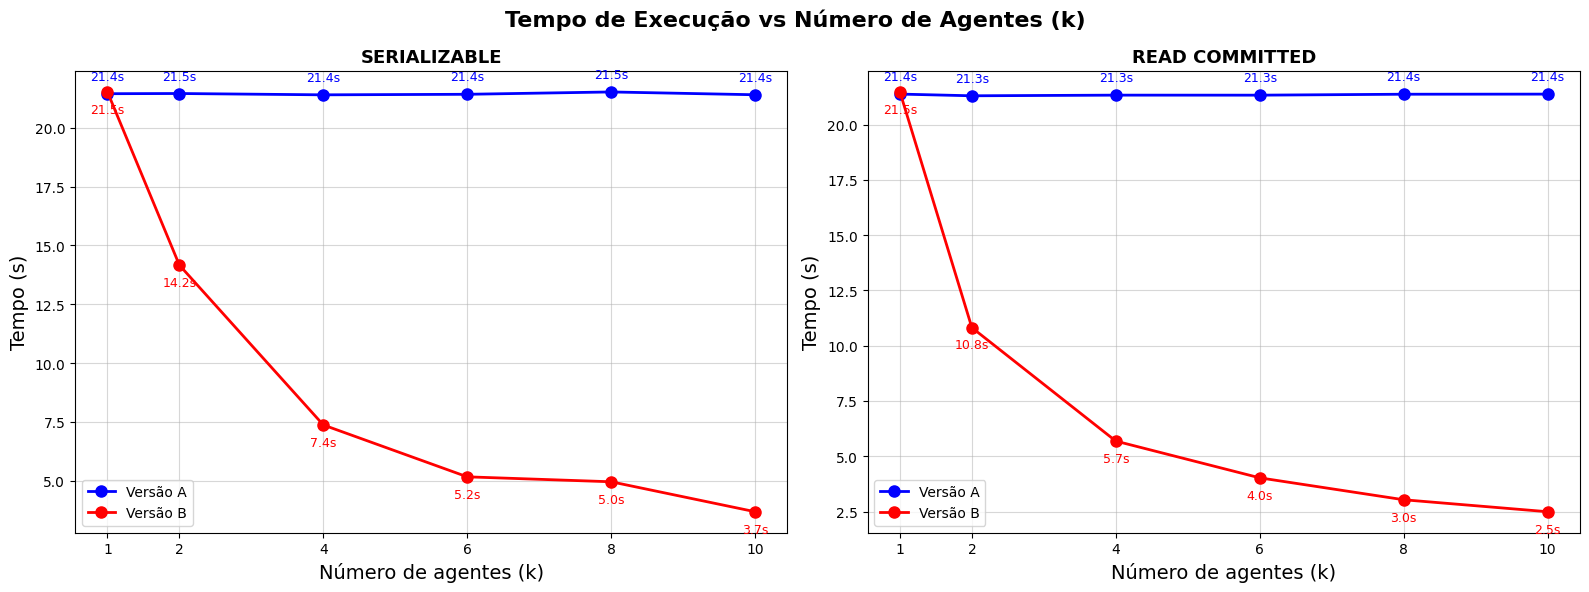

In [7]:
all_runner = ExperimentRunner()
all_runner.run_all_experiments()
all_runner.plot_results()

## Tarefa 19

In [8]:
all_runner.create_retry_table()

Nível de Isolamento: READ COMMITTED
 k  Min_A  Max_A Avg_A  Min_B  Max_B Avg_B
 1      1      1  1.00      1      1  1.00
 2      1      1  1.00      1      2  1.01
 4      1      1  1.00      1      3  1.05
 6      1      1  1.00      1      4  1.06
 8      1      1  1.00      1      3  1.06
10      1      1  1.00      1      3  1.07
Nível de Isolamento: SERIALIZABLE
 k  Min_A  Max_A Avg_A  Min_B  Max_B Avg_B
 1      1      1  1.00      1      1  1.00
 2      1     37  2.00      1      7  1.48
 4      1    121  3.88      1      7  1.39
 6      1     60  4.96      1      7  1.59
 8      1     54  5.47      1     11  2.06
10      1     41  6.02      1     12  2.02


## Tarefa 20

Vamos analisar os gráficos separadamente para cada versão da transação.
Para a versão A:
Se manteve em uma constante de 200 (com breves variações em ambas as execuções) isso se deve ao fato de que apenas uma thread consegue reservar um assento por vez, fazendo com que as outras threads esperem a liberação do lock. Essa justificativa aplicasse de maneira independente ao nível de isolamento utilizado, pois, ambos os níveis só permitem novas leituras de dados uma vez que a transação atual seja finalizada (commit ou rollback).

Para a versão B:
No nível de isolamento SERIALIZABLE, o tempo foi diminuindo a medida que o número de agentes aumentava, isso se deve ao fato de que mais threads estão tentando reservar assentos simultaneamente, aumentando a chance de sucesso em cada tentativa, porém, observa-se que quando a quantidade de agentes ultrapassa 6, o tempo começa a aumentar novamente, isso se deve ao fato de que muitas threads estão competindo pelos mesmos recursos, causando contenção e aumentando o tempo de espera. Já no nível READ COMMITTED, o tempo diminui de forma mais consistente com o aumento do número de agentes, isso se deve ao fato de que esse nível de isolamento permite maior concorrência, reduzindo a contenção entre as threads e melhorando o desempenho geral do sistema, uma vez que o read commited permite leitura de dados já commitados, e uma vez que temos um commit já no meio, é permitida que outras leituras sejam feitas já naquele momento antes mesmo da escolha do assento.

No geral a versão B se mostrou mais eficiente, principalmente no nível READ COMMITTED, devido a sua capacidade de permitir maior concorrência e reduzir a contenção entre as threads uma vez que as outrhas threads não dependiam da escolha do assento (demorava 1 segundo) de outra thread.